# ZINC-250K Dataset Visualisations
Exploring drug-likeness patterns across the ZINC-250K molecular library.

In [1]:
!pip install pandas matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
    sys-platform (=="darwin") ; extra == 'objc'
                 ~^


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
with open("atom_data.json", "r") as f:
    atom_data = json.load(f)

df = pd.read_csv("molecules_clean.csv")
df["smiles"] = df["smiles"].str.strip()

# Compute per-molecule features from atom_data.json
mol_features = []
for mol in atom_data:
    smiles = mol["smiles"].strip()
    atoms = mol["atoms"]
    heavy_atoms = [a for a in atoms if a["symbol"] != "H"]
    aromatic_atoms = [a for a in heavy_atoms if a["is_aromatic"]]
    total_heavy = len(heavy_atoms)
    num_aromatic = len(aromatic_atoms)
    aromatic_ratio = num_aromatic / total_heavy if total_heavy > 0 else 0
    symbols = [a["symbol"] for a in heavy_atoms]
    mol_features.append({
        "smiles": smiles,
        "total_heavy_atoms": total_heavy,
        "num_aromatic": num_aromatic,
        "aromatic_ratio": aromatic_ratio,
        "num_carbon": symbols.count("C"),
        "num_nitrogen": symbols.count("N"),
        "num_oxygen": symbols.count("O"),
        "num_sulfur": symbols.count("S"),
        "num_chlorine": symbols.count("Cl"),
        "num_fluorine": symbols.count("F"),
    })

feat_df = pd.DataFrame(mol_features)
merged = pd.merge(df, feat_df, on="smiles", how="inner")
print(f"CSV rows: {len(df)}, JSON molecules: {len(atom_data)}, Merged: {len(merged)}")

CSV rows: 10000, JSON molecules: 10000, Merged: 10000


In [2]:
# Style setup
BG = "#0f1117"
CARD_BG = "#1a1d27"
ACCENT = "#6C63FF"
ACCENT2 = "#00D4AA"
TEXT = "#e0e0e0"
SUBTLE = "#6b7280"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": CARD_BG,
    "axes.edgecolor": "#2a2d3a",
    "axes.labelcolor": TEXT,
    "xtick.color": SUBTLE,
    "ytick.color": SUBTLE,
    "text.color": TEXT,
    "font.family": "monospace",
    "font.size": 11,
    "grid.color": "#2a2d3a",
    "grid.alpha": 0.5,
})

## QED Score Distribution
Shows the spread of drug-likeness across ZINC-250K. Even within a pre-filtered "drug-like" library, quality varies widely.

/tmp/ipykernel_526095/4148115017.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn")


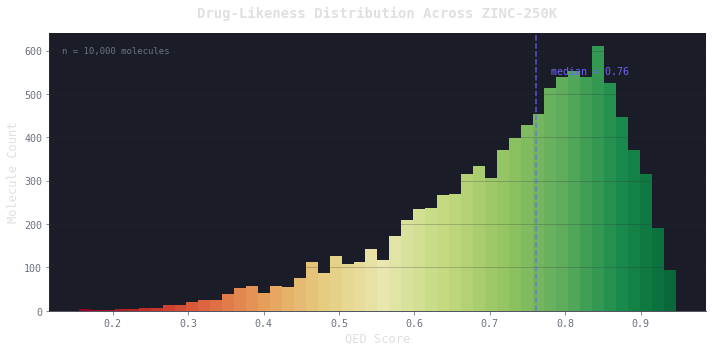

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

counts, bins, patches = ax.hist(merged["qed"], bins=50, edgecolor="none", alpha=0.9)

norm = plt.Normalize(bins.min(), bins.max())
cmap = plt.cm.get_cmap("RdYlGn")
for patch, left_edge in zip(patches, bins[:-1]):
    patch.set_facecolor(cmap(norm(left_edge)))

median_qed = merged["qed"].median()
ax.axvline(median_qed, color=ACCENT, linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(median_qed + 0.02, ax.get_ylim()[1] * 0.85,
        f"median = {median_qed:.2f}", color=ACCENT, fontsize=10)

ax.set_xlabel("QED Score", fontsize=12)
ax.set_ylabel("Molecule Count", fontsize=12)
ax.set_title("Drug-Likeness Distribution Across ZINC-250K",
             fontsize=14, fontweight="bold", pad=15)
ax.text(0.02, 0.95, f"n = {len(merged):,} molecules",
        transform=ax.transAxes, fontsize=9, color=SUBTLE, va="top")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Model vs Baseline Property Distributions (Box Plots)
Compares key properties (QED, LogP, MW, TPSA, HBD, HBA) between model-generated molecules and baseline ZINC molecules.

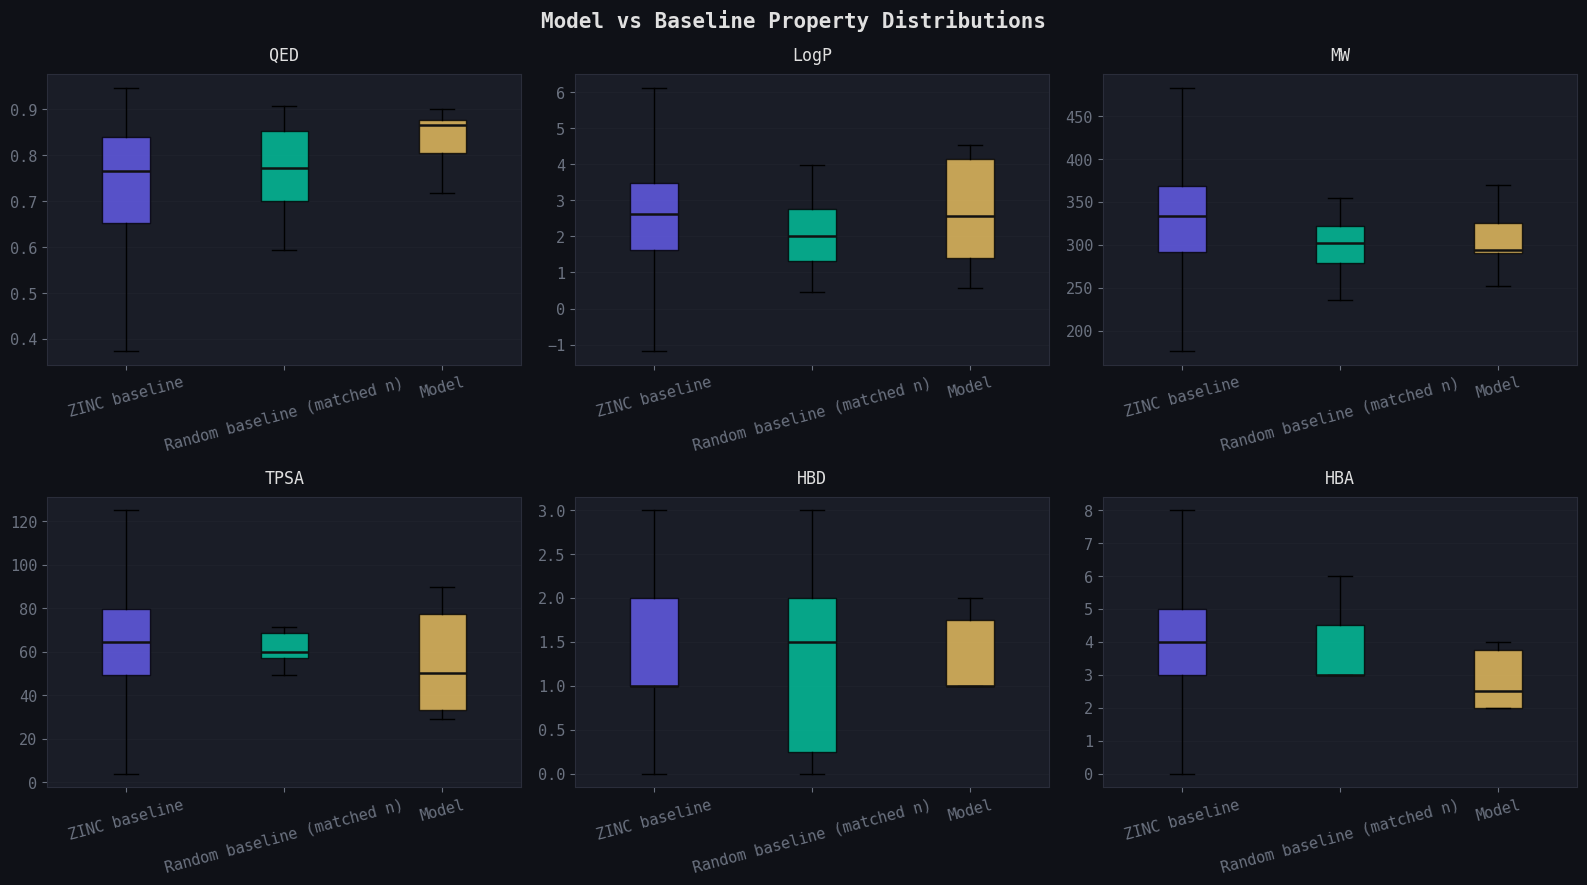

Counts by source:
Source
Model                              6
Random baseline (matched n)        6
ZINC baseline                  10000


In [4]:
import os
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, QED

PROPERTIES = ["QED", "LogP", "MW", "TPSA", "HBD", "HBA"]

def compute_properties(smiles_list, source_label):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(str(smi).strip())
        if mol is None:
            continue
        rows.append({
            "Source": source_label,
            "QED": float(QED.qed(mol)),
            "LogP": float(Descriptors.MolLogP(mol)),
            "MW": float(Descriptors.ExactMolWt(mol)),
            "TPSA": float(Descriptors.TPSA(mol)),
            "HBD": float(rdMolDescriptors.CalcNumHBD(mol)),
            "HBA": float(rdMolDescriptors.CalcNumHBA(mol)),
        })
    return pd.DataFrame(rows)

# Baseline from ZINC in this notebook
baseline_smiles = merged["smiles"].dropna().astype(str).unique().tolist()
baseline_df = compute_properties(baseline_smiles, "ZINC baseline")

# Model candidates: pool used in run_pipeline.py + optional generated SDF output
model_smiles = [
    "C[NH+]1CCC(NC(=O)[C@H]2CCN(c3ccc(Cl)c(Cl)c3)C2=O)CC1",
    "CC(C)(C)C(=O)Nc1sc(CC(N)=O)nc1-c1cccc(F)c1",
    "O=C(Nc1cccc(Cl)c1)c1sc2c(c1)CCCC2",
    "CC1(C)CC(=O)C2(C)C(O)CC3OCC3(C)C2C1",
    "COc1ccc(S(=O)(=O)N2CCC(C(N)=O)CC2)cc1",
]

sdf_path = Path("../outputs/generated_drug.sdf")
if sdf_path.exists():
    sdf_supplier = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
    for mol in sdf_supplier:
        if mol is not None:
            smi = Chem.MolToSmiles(Chem.RemoveHs(mol), canonical=True)
            model_smiles.append(smi)

# Optional user-provided CSVs with a smiles column
for optional_csv in ["../outputs/generated_smiles.csv", "../outputs/model_smiles.csv"]:
    csv_path = Path(optional_csv)
    if csv_path.exists():
        temp_df = pd.read_csv(csv_path)
        if "smiles" in temp_df.columns:
            model_smiles.extend(temp_df["smiles"].dropna().astype(str).tolist())

model_smiles = sorted(set(model_smiles))
model_df = compute_properties(model_smiles, "Model")

# Optional matched-size random baseline to make small-model comparisons fairer
matched_n = max(len(model_df), 1)
matched_smiles = merged["smiles"].dropna().sample(
    n=min(matched_n, len(merged)), random_state=42
).astype(str).tolist()
matched_df = compute_properties(matched_smiles, "Random baseline (matched n)")

comparison_df = pd.concat([baseline_df, matched_df, model_df], ignore_index=True)

if comparison_df.empty:
    raise ValueError("No molecules available to plot. Check input files and SMILES validity.")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

sources = ["ZINC baseline", "Random baseline (matched n)", "Model"]
palette = [ACCENT, ACCENT2, "#FFD166"]

for i, prop in enumerate(PROPERTIES):
    ax = axes[i]
    grouped = [comparison_df.loc[comparison_df["Source"] == src, prop].dropna().values for src in sources]

    bp = ax.boxplot(
        grouped,
        tick_labels=sources,
        patch_artist=True,
        showfliers=False,
    )

    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp["medians"]:
        median.set_color("#111111")
        median.set_linewidth(1.8)

    ax.set_title(prop, fontsize=12, pad=10)
    ax.tick_params(axis="x", labelrotation=15)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Model vs Baseline Property Distributions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print("Counts by source:")
print(comparison_df.groupby("Source").size().to_string())